In [1]:
# Import libraries
import sys
sys.path.append('../')
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

In [2]:
df_part = pd.read_csv('../data/polymod/participants.csv')
df_cnt = pd.read_csv('../data/polymod/contacts.csv')

In [3]:
subset_cols = [
    'id',
 	'participant_age',
	'participant_gender',
	'participant_occupation',
	'participant_education',
	'hh_size'
]
df_part = df_part[subset_cols]
df_part.columns = ['id', 'age_part', 'sex_part', 'occ_part', 'edu_part', 'hh_size']

In [4]:
subset_cols = [
	'part_id',
	'cnt_age_exact',
 	'cnt_age_est_min',
    'cnt_age_est_max',
    'cnt_gender',
    'cnt_home',
    'cnt_work',
    'cnt_school',
    'cnt_transport',
    'cnt_leisure',
    'cnt_otherplace'
]
df_cnt = df_cnt[subset_cols]
df_cnt.columns = ['id', 'age_cnt', 'age_cnt_min', 'age_cnt_max', 'sex_cnt', 'y_home', 'y_work', 'y_school', 'y_transport', 'y_leisure', 'y_other']

In [5]:
df = pd.merge(df_part, df_cnt, on='id', how='inner')

In [6]:
def impute_age_min_max(data: pd.DataFrame,
                       age_col: str,
					   age_min_col: str,
					   age_max_col: str,
        			   dropna: bool=False,
              		   remove_min_max_col: bool=True) -> pd.DataFrame:
    data = data.copy()
    data[age_col] = np.where(data[age_col].isna(), 
                             (data[age_min_col] + data[age_max_col]) // 2,
							 data[age_col])
    
    if dropna:
        n0 = data.shape[0]
        data = data.dropna(subset=[age_col])
        n1 = data.shape[0]
        Warning(f'Dropped {n0 - n1} rows with missing values in {age_col}')
        data[age_col] = data[age_col].astype(int)
    
    if remove_min_max_col:
        data = data.drop(columns=[age_min_col, age_max_col], axis=1)
    
    return data

df = impute_age_min_max(df, 'age_cnt', 'age_cnt_min', 'age_cnt_max', dropna=True)

In [7]:
# Drop rows with missing values in age_part and sex_part
df = df.dropna(subset=['age_part', 'sex_part'])

In [8]:
y_cols = ['y_home', 'y_work', 'y_school', 'y_transport', 'y_leisure', 'y_other']
df['y'] = np.sum(df[y_cols].values, axis=1)
df = df.drop(columns=y_cols, axis=1)

In [13]:
from cntmosaic.preprocess import make_train_data

df_train = make_train_data(df, 'id', ['sex_part'])

In [20]:
from cntmosaic.visuals import plot_cint_marginal, plot_cint_matrix

# Empirical contact intensity
df_train['cint'] = df_train['y'] / df_train['N']

df_pivot = pd.pivot_table(df_train, values='cint', index=['age_part', 'sex_part'], columns='age_cnt')
df_pivot = df_pivot.reset_index()

cnt_men = df_pivot[df_pivot['sex_part'] == 'M'].drop('age_cnt', axis=1).values.T
cnt_women = df_pivot[df_pivot['sex_part'] == 'F'].drop('age_cnt', axis=1).values.T

/var/folders/fc/szc97hhx4sgg1mzfl9bt0n240000gn/T/ipykernel_29812/3753322384.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df_pivot = pd.pivot_table(df_train, values='cint', index=['age_part', 'sex_part'], columns='age_cnt')


KeyError: "['age_cnt'] not found in axis"

In [29]:
df_pivot[df_pivot['sex_part'] == 'M']

age_cnt,age_part,sex_part,0,1,2,3,4,5,6,7,...,76,77,78,79,80,81,82,83,84,85
1,0,M,0.0,0.000000,0.125,0.000000,0.000000,0.125000,0.000000,0.125000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,1,M,0.0,0.000000,0.000,0.000000,0.000000,0.333333,0.833333,0.666667,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
5,2,M,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.2,0.000000,0.2,0.2,0.0,0.000000,0.0,0.0,0.0
7,3,M,0.0,0.111111,0.000,0.111111,0.222222,0.000000,0.000000,0.000000,...,0.222222,0.0,0.111111,0.0,0.0,0.0,0.111111,0.0,0.0,0.0
9,4,M,0.0,0.000000,0.000,0.000000,0.142857,0.285714,0.571429,0.285714,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.428571,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,74,M,0.0,0.000000,0.000,0.500000,0.500000,2.750000,0.000000,2.500000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
150,75,M,0.0,2.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,2.0
153,77,M,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
158,82,M,0.0,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


In [7]:
# Group contacts
df_part['class_size'] = df_part['class_size'].fillna(0)
df_part['work_contacts_nr'] = df_part['work_contacts_nr'].fillna(0)
df_part['y_grp'] = df_part['class_size'] + df_part['work_contacts_nr']
df_part['y_grp'] = df_part['y_grp'].apply(lambda x: min(x, 60))
df_grp = df_part.groupby('age_part').agg({'y_grp': 'sum'}).reset_index()

In [8]:
# Combine participant information and contact information
df_merged = pd.merge(df_cnt, df_part,
                     how='left',
                     left_on='part_id',
                     right_on='global_id')

# Count the number of contacts by age of participant and contact
df_sum = df_merged.groupby(['age_part', 'sex_part', 'age_cnt', 'sex_cnt']).size().reset_index(name='y')
print(df_sum.shape)

(5961, 5)


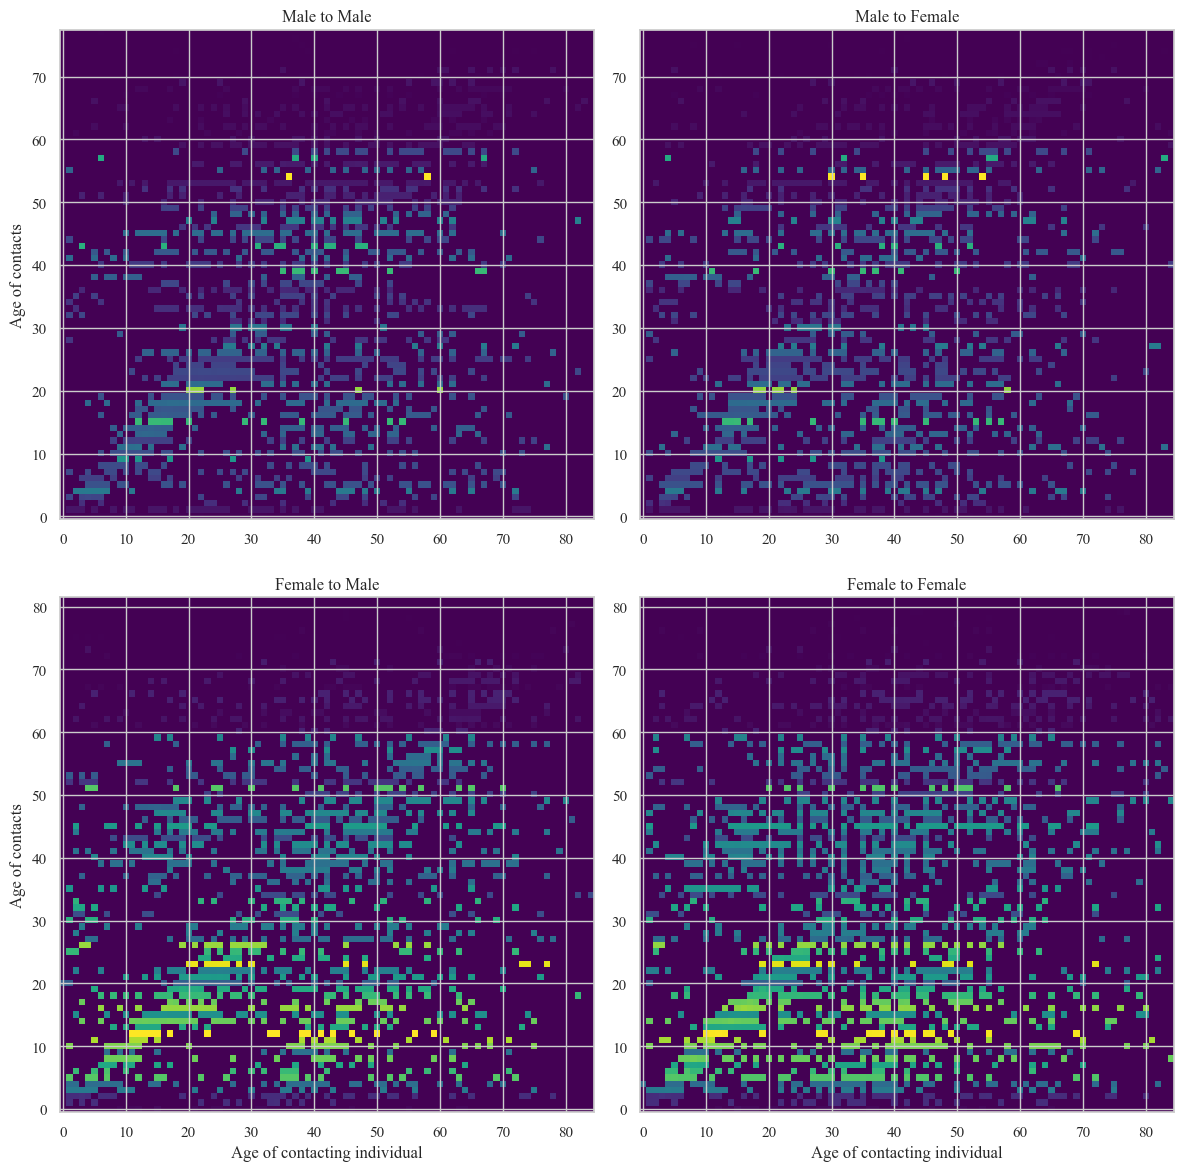

In [11]:
def plot_contact_matrix(df, ax, sex_part, sex_cnt, show_xlabel=True, show_ylabel=True):
  sex_part_label = 'Male' if sex_part == 'M' else 'Female'
  sex_cnt_label = 'Male' if sex_cnt == 'M' else 'Female' 

  df = df[(df['sex_part'] == sex_part) & (df['sex_cnt'] == sex_cnt)]
  x = df.pivot(index='age_part', columns='age_cnt', values='m').to_numpy()
  ax.imshow(x, cmap='viridis')
  ax.yaxis.set_inverted(False)
  if show_xlabel:
    ax.set_xlabel('Age of contacting individual')
  if show_ylabel:
    ax.set_ylabel('Age of contacts')
  ax.set_title('{} to {}'.format(sex_part_label, sex_cnt_label))

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

plot_contact_matrix(df_sum, ax[0,0], 'M', 'M', show_xlabel=False)
plot_contact_matrix(df_sum, ax[0,1], 'M', 'F', show_xlabel=False, show_ylabel=False)
plot_contact_matrix(df_sum, ax[1,0], 'F', 'M')
plot_contact_matrix(df_sum, ax[1,1], 'F', 'F', show_ylabel=False)

fig.tight_layout()
plt.show()

In [12]:
# Save preprocessed data
df_sum.to_csv('../data/polymod/fine_age.csv', index=False)